In [ ]:
# === Colab 호환 셋업 (자동 추가) ===
import torch as _t
_t._orig_load = getattr(_t, '_orig_load', _t.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return _t._orig_load(*a, **k)
_t.load = _compat_load
try:
    import matplotlib; matplotlib.rcParams['axes.unicode_minus'] = False
except Exception: pass
print('[colab-compat] torch.load weights_only=False 패치 적용')

[colab-compat] torch.load weights_only=False 패치 적용


한국어 폰트 설정하기

In [ ]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 57 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,345 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


# 데이터 준비

https://github.com/jungyeul/korean-parallel-corpora

In [ ]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.11.0+cu128


In [ ]:
import tarfile
import shutil

dataset_dir = os.path.join(os.path.expanduser("/content/datasets"), "korean-english-park")
os.makedirs(dataset_dir, exist_ok=True)

train_tar = "/content/korean-english-park.train.tar.gz"
test_tar = "/content/korean-english-park.test.tar.gz"

# 업로드된 파일을 dataset_dir로 복사
for src in [train_tar, test_tar]:
    dst = os.path.join(dataset_dir, os.path.basename(src))
    if not os.path.exists(dst):
        shutil.copy(src, dst)

# 압축 해제
for fname in ["korean-english-park.train.tar.gz", "korean-english-park.test.tar.gz"]:
    tar_path = os.path.join(dataset_dir, fname)
    print(f"{fname} 압축 해제 중...")
    with tarfile.open(tar_path, "r:gz") as tar_ref:
        tar_ref.extractall(dataset_dir)
    print(f"{fname} 압축 해제 완료!")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))

korean-english-park.train.tar.gz 압축 해제 중...
korean-english-park.train.tar.gz 압축 해제 완료!
korean-english-park.test.tar.gz 압축 해제 중...
korean-english-park.test.tar.gz 압축 해제 완료!
데이터셋 디렉토리: ['korean-english-park.test.ko', 'korean-english-park.train.tar.gz', 'korean-english-park.train.ko', 'korean-english-park.test.tar.gz', 'korean-english-park.test.en', 'korean-english-park.train.en']


/tmp/ipykernel_597/1330527890.py:21: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar_ref.extractall(dataset_dir)


In [ ]:
train_ko_path = os.path.join(dataset_dir, "korean-english-park.train.ko")
train_en_path = os.path.join(dataset_dir, "korean-english-park.train.en")
test_ko_path = os.path.join(dataset_dir, "korean-english-park.test.ko")
test_en_path = os.path.join(dataset_dir, "korean-english-park.test.en")

In [ ]:
with open(train_ko_path, encoding="utf-8") as f:
    train_ko = [line.strip() for line in f]
with open(train_en_path, encoding="utf-8") as f:
    train_en = [line.strip() for line in f]

with open(test_ko_path, encoding="utf-8") as f:
    test_ko = [line.strip() for line in f]
with open(test_en_path, encoding="utf-8") as f:
    test_en = [line.strip() for line in f]

print(len(train_ko), len(train_en), len(test_ko), len(test_en))
print(train_ko[0])
print(train_en[0])

94123 94123 2000 2000
개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
Much of personal computing is about "can you top this?"


# EDA

In [ ]:
def basic_stats(name, lines):
    lengths_char = [len(s) for s in lines]
    lengths_word = [len(s.split()) for s in lines]
    print(f"[{name}]")
    print(f"  문장 수: {len(lines)}")
    print(f"  빈 문장 수: {sum(1 for s in lines if len(s.strip()) == 0)}")
    print(f"  평균 글자 수: {np.mean(lengths_char):.1f} / 최대: {max(lengths_char)}")
    print(f"  평균 단어 수: {np.mean(lengths_word):.1f} / 최대: {max(lengths_word)}")
    print()

basic_stats("train_ko", train_ko)
basic_stats("train_en", train_en)
basic_stats("test_ko", test_ko)
basic_stats("test_en", test_en)

[train_ko]
  문장 수: 94123
  빈 문장 수: 0
  평균 글자 수: 60.8 / 최대: 377
  평균 단어 수: 14.0 / 최대: 82

[train_en]
  문장 수: 94123
  빈 문장 수: 0
  평균 글자 수: 126.1 / 최대: 605
  평균 단어 수: 20.9 / 최대: 90

[test_ko]
  문장 수: 2000
  빈 문장 수: 0
  평균 글자 수: 66.9 / 최대: 219
  평균 단어 수: 15.4 / 최대: 55

[test_en]
  문장 수: 2000
  빈 문장 수: 0
  평균 글자 수: 137.9 / 최대: 410
  평균 단어 수: 22.8 / 최대: 69



In [ ]:
from collections import Counter

def vocab_stats(name, lines):
    counter = Counter()
    for s in lines:
        counter.update(s.split())
    print(f"[{name}] 고유 단어 수: {len(counter)}")
    print(f"  가장 흔한 단어 20개: {counter.most_common(20)}")
    print()
    return counter

ko_counter = vocab_stats("train_ko", train_ko)
en_counter = vocab_stats("train_en", train_en)

[train_ko] 고유 단어 수: 241552
  가장 흔한 단어 20개: [('이', 7920), ('밝혔다.', 7838), ('말했다.', 6953), ('있다.', 6942), ('수', 6301), ('있는', 6067), ('그는', 5124), ('대한', 4406), ('위해', 4272), ('전했다.', 3817), ('이번', 3719), ('지난', 3610), ('한', 3576), ('대해', 3238), ('미국', 3157), ('것으로', 2978), ('전', 2960), ('것이라고', 2939), ('것을', 2852), ('있다고', 2807)]

[train_en] 고유 단어 수: 110099
  가장 흔한 단어 20개: [('the', 109097), ('to', 53871), ('of', 51188), ('a', 45948), ('in', 44377), ('and', 42495), ('for', 17523), ('on', 17088), ('The', 16967), ('that', 16527), ('is', 14399), ('was', 13229), ('said', 12971), ('with', 12046), ('as', 10013), ('at', 9866), ('by', 9495), ('from', 9331), ('has', 8783), ('his', 8455)]



구두점 제거가 필요해 보인다

단어 수가 많아 토크나이저에서 num_words 제한이 필요해 보인다

In [ ]:
def check_duplicates(name, lines):
    dup_count = len(lines) - len(set(lines))
    print(f"[{name}] 중복 문장 수: {dup_count} ({dup_count/len(lines)*100:.2f}%)")

check_duplicates("train_ko", train_ko)
check_duplicates("train_en", train_en)

[train_ko] 중복 문장 수: 16562 (17.60%)
[train_en] 중복 문장 수: 18525 (19.68%)


In [ ]:
def contains_pattern(lines, pattern, name):
    count = sum(1 for s in lines if re.search(pattern, s))
    print(f"{name}: {count}개 문장 ({count/len(lines)*100:.2f}%)")

contains_pattern(train_ko, r"[a-zA-Z]", "영어 알파벳 포함 (한국어 문장)")
contains_pattern(train_ko, r"\d", "숫자 포함")
contains_pattern(train_ko, r"[^\w\s가-힣]", "특수문자 포함")

영어 알파벳 포함 (한국어 문장): 17940개 문장 (19.06%)
숫자 포함: 39955개 문장 (42.45%)
특수문자 포함: 90675개 문장 (96.34%)


# 데이터 전처리

In [ ]:
!sudo apt-get update
!sudo apt-get install -y mecab libmecab-dev mecab-ipadic-utf8

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [4,685 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,578 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [113 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,920 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.8 MB]
Hit:13 https://ppa.launchpadcontent.net/graphics-driv

In [ ]:
!pip install python-mecab-ko

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 59.3 MB/s eta 0:00:00
  Created wheel for python-mecab-ko: filename=python_mecab_ko-1.3.7-cp313-cp313-linux_x86_64.whl size=276054 sha256=a5b5fdf50db35dc9228d24b0c35300288e21016a6a25b653aa49f190b7f8c3f7
  Stored in directory: /root/.cache/pip/wheels/0b/41/fc/beec44af29714f2564f1ed6cb5601790f1eddaec424506a0b3
Successfully built python-mecab-ko


In [ ]:
from mecab import MeCab

mecab = MeCab()
print(mecab.morphs("개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐?"))

['개인', '용', '컴퓨터', '사용', '의', '상당', '부분', '은', '이것', '보다', '뛰어날', '수', '있', '느냐', '?']


In [ ]:
def remove_duplicate_pairs(ko_lines, en_lines):
    seen = set()
    ko_dedup, en_dedup = [], []

    for ko, en in zip(ko_lines, en_lines):
        pair = (ko, en)
        if pair not in seen:
            seen.add(pair)
            ko_dedup.append(ko)
            en_dedup.append(en)

    return ko_dedup, en_dedup

before = len(train_ko)
train_ko, train_en = remove_duplicate_pairs(train_ko, train_en)
after = len(train_ko)

print(f"제거 전: {before}개")
print(f"제거 후: {after}개")
print(f"제거된 중복 쌍: {before - after}개 ({(before - after) / before * 100:.2f}%)")

제거 전: 94123개
제거 후: 78941개
제거된 중복 쌍: 15182개 (16.13%)


In [ ]:
import re
import unicodedata

def preprocess_sentence_ko(sentence, mecab):
    # 유니코드 정규화 (자모 분리 방지)
    sentence = unicodedata.normalize("NFKC", sentence.strip())

    # Mecab 형태소 분석기로 문장을 형태소 단위로 분리 -> 어휘 크기 감소
    morphs = mecab.morphs(sentence)

    # 분리된 형태소들을 공백으로 이어 하나의 문자열로 반환
    return " ".join(morphs)

def preprocess_sentence_en(sentence):
    # 유니코드 정규화 + 앞뒤 공백 제거 + 소문자 변환
    sentence = unicodedata.normalize("NFKC", sentence.strip()).lower()

    # 구두점 앞뒤에 공백을 추가하여 단어와 분리
    sentence = re.sub(r"([?.!,¿'\"“”])", r" \1 ", sentence)

    # 알파벳, 숫자, 허용된 구두점을 제외한 모든 문자를 공백으로 치환
    sentence = re.sub(r"[^a-zA-Z0-9?.!,¿'\"“”]+", " ", sentence)

    # 여러 개의 연속된 공백을 하나로 합치고 앞뒤 공백 제거
    sentence = re.sub(r"\s+", " ", sentence).strip()

    return sentence

def preprocess_corpus_ko(lines, mecab):
    return [preprocess_sentence_ko(s, mecab) for s in lines]

def preprocess_corpus_en(lines):
    return [preprocess_sentence_en(s) for s in lines]


# train, test 데이터에 각각 전처리 함수 적용
train_ko_processed = preprocess_corpus_ko(train_ko, mecab)
train_en_processed = preprocess_corpus_en(train_en)
test_ko_processed = preprocess_corpus_ko(test_ko, mecab)
test_en_processed = preprocess_corpus_en(test_en)

print(train_ko_processed[0])
print(train_en_processed[0])

개인 용 컴퓨터 사용 의 상당 부분 은 " 이것 보다 뛰어날 수 있 느냐 ? "
much of personal computing is about " can you top this ? "


In [ ]:
before = len(train_ko_processed)

train_ko_processed, train_en_processed = remove_duplicate_pairs(
    train_ko_processed,
    train_en_processed
)

after = len(train_ko_processed)

print(f"전처리 후 중복 제거 전: {before}개")
print(f"전처리 후 중복 제거 후: {after}개")
print(f"제거된 중복 쌍: {before - after}개 ({(before - after) / before * 100:.2f}%)")

전처리 후 중복 제거 전: 78941개
전처리 후 중복 제거 후: 78919개
제거된 중복 쌍: 22개 (0.03%)


- `max_length` 정하기

In [ ]:
train_ko_len = [len(s.split()) for s in train_ko_processed]
train_en_len = [len(s.split()) for s in train_en_processed]

print("한국어(형태소) 평균 길이:", np.mean(train_ko_len), "/ 최대:", max(train_ko_len))
print("영어 평균 길이:", np.mean(train_en_len), "/ 최대:", max(train_en_len))

for p in [90, 95, 99, 99.5]:
    print(f"한국어 {p}% 지점: {np.percentile(train_ko_len, p):.1f}")
for p in [90, 95, 99, 99.5]:
    print(f"영어 {p}% 지점: {np.percentile(train_en_len, p):.1f}")

한국어(형태소) 평균 길이: 30.53419328678772 / 최대: 129
영어 평균 길이: 25.989482887517582 / 최대: 101
한국어 90% 지점: 48.0
한국어 95% 지점: 54.0
한국어 99% 지점: 67.0
한국어 99.5% 지점: 72.0
영어 90% 지점: 41.0
영어 95% 지점: 46.0
영어 99% 지점: 57.0
영어 99.5% 지점: 62.0


In [ ]:
def truncation_stats(lines, max_lengths, name=""):
    lengths = np.array([len(s.split()) for s in lines])
    total = len(lengths)

    print(f"[{name}] 전체 문장 수: {total}")
    for max_len in max_lengths:
        n_truncated = np.sum(lengths > max_len)
        pct = n_truncated / total * 100
        print(f"  max_length={max_len:>3} → 잘리는 문장: {n_truncated:>6}개 ({pct:.2f}%)")
    print()

candidate_lengths_ko = [30, 40, 45, 50, 55, 60, 70]
candidate_lengths_en = [30, 40, 45, 50, 55, 60, 70]

truncation_stats(train_ko_processed, candidate_lengths_ko, name="train_ko")
truncation_stats(train_en_processed, candidate_lengths_en, name="train_en")

[train_ko] 전체 문장 수: 78919
  max_length= 30 → 잘리는 문장:  36813개 (46.65%)
  max_length= 40 → 잘리는 문장:  16200개 (20.53%)
  max_length= 45 → 잘리는 문장:   9788개 (12.40%)
  max_length= 50 → 잘리는 문장:   5619개 (7.12%)
  max_length= 55 → 잘리는 문장:   3165개 (4.01%)
  max_length= 60 → 잘리는 문장:   1720개 (2.18%)
  max_length= 70 → 잘리는 문장:    512개 (0.65%)

[train_en] 전체 문장 수: 78919
  max_length= 30 → 잘리는 문장:  25209개 (31.94%)
  max_length= 40 → 잘리는 문장:   8589개 (10.88%)
  max_length= 45 → 잘리는 문장:   4378개 (5.55%)
  max_length= 50 → 잘리는 문장:   2120개 (2.69%)
  max_length= 55 → 잘리는 문장:   1041개 (1.32%)
  max_length= 60 → 잘리는 문장:    475개 (0.60%)
  max_length= 70 → 잘리는 문장:    130개 (0.16%)



In [ ]:
def pair_truncation_stats(ko_lines, en_lines, max_len_ko, max_len_en):
    ko_lengths = np.array([len(s.split()) for s in ko_lines])
    en_lengths = np.array([len(s.split()) for s in en_lines])

    ko_over = ko_lengths > max_len_ko
    en_over = en_lengths > max_len_en
    either_over = ko_over | en_over

    total = len(ko_lines)
    print(f"전체 문장 쌍: {total}")
    print(f"한국어만 초과: {np.sum(ko_over & ~en_over)}개")
    print(f"영어만 초과: {np.sum(en_over & ~ko_over)}개")
    print(f"둘 다 초과: {np.sum(ko_over & en_over)}개")
    print(f"둘 중 하나라도 초과 (제외 대상): {np.sum(either_over)}개 ({np.sum(either_over)/total*100:.2f}%)")
    print(f"남는 문장 쌍: {total - np.sum(either_over)}개")

pair_truncation_stats(train_ko_processed, train_en_processed, max_len_ko=55, max_len_en=50)

전체 문장 쌍: 78919
한국어만 초과: 2268개
영어만 초과: 1223개
둘 다 초과: 897개
둘 중 하나라도 초과 (제외 대상): 4388개 (5.56%)
남는 문장 쌍: 74531개


**max_length**

한국어: 55, 영어: 50

In [ ]:
MAX_LEN_KO = 55
MAX_LEN_EN = 50


def filter_by_length(ko_lines, en_lines, max_len_ko, max_len_en):
    filtered_ko, filtered_en = [], []
    for ko, en in zip(ko_lines, en_lines):
        if len(ko.split()) <= max_len_ko and len(en.split()) <= max_len_en:
            filtered_ko.append(ko)
            filtered_en.append(en)
    return filtered_ko, filtered_en


# 둘 중 하나라도 초과하는 문장 쌍 제거
train_ko_filtered, train_en_filtered = filter_by_length(
    train_ko_processed, train_en_processed, MAX_LEN_KO, MAX_LEN_EN
)

print(f"필터링 전: {len(train_ko_processed)}개")
print(f"필터링 후: {len(train_ko_filtered)}개")
print(f"제거된 문장 쌍: {len(train_ko_processed) - len(train_ko_filtered)}개 "
      f"({(len(train_ko_processed) - len(train_ko_filtered)) / len(train_ko_processed) * 100:.2f}%)")

필터링 전: 78919개
필터링 후: 74531개
제거된 문장 쌍: 4388개 (5.56%)


In [ ]:
# SentencePiece 학습용 코퍼스 파일 저장
with open("ko_corpus.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(train_ko_filtered))

with open("en_corpus.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(train_en_filtered))

print("파일 저장 완료: ko_corpus.txt, en_corpus.txt")

파일 저장 완료: ko_corpus.txt, en_corpus.txt


In [ ]:
# SentencePiece 학습
import sentencepiece as spm

vocab_size = 8000
pad_id, bos_id, eos_id, unk_id = 0, 1, 2, 3

spm.SentencePieceTrainer.train(
    input="ko_corpus.txt",
    model_prefix="encoder_spm",
    vocab_size=vocab_size,
    pad_id=pad_id, bos_id=bos_id, eos_id=eos_id, unk_id=unk_id
)

spm.SentencePieceTrainer.train(
    input="en_corpus.txt",
    model_prefix="decoder_spm",
    vocab_size=vocab_size,
    pad_id=pad_id, bos_id=bos_id, eos_id=eos_id, unk_id=unk_id
)

True

In [ ]:
# 토크나이저 로드
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

sample = train_ko_filtered[0]
print("원문:", sample)
print("pieces:", encoder_tokenizer.encode_as_pieces(sample))
print("ids:", encoder_tokenizer.encode_as_ids(sample))

원문: 개인 용 컴퓨터 사용 의 상당 부분 은 " 이것 보다 뛰어날 수 있 느냐 ? "
pieces: ['▁개인', '▁용', '▁컴퓨터', '▁사용', '▁의', '▁상당', '▁부분', '▁은', '▁"', '▁이것', '▁보다', '▁뛰', '어', '날', '▁수', '▁있', '▁느냐', '▁', '?', '▁"']
ids: [990, 465, 783, 225, 10, 1906, 1240, 12, 58, 1088, 208, 2150, 173, 2273, 44, 19, 3830, 4, 7954, 58]


In [ ]:
# train 인코딩
def encode_corpus(tokenizer, lines, add_bos=True, add_eos=True):
    return [tokenizer.encode(s, out_type=int, add_bos=add_bos, add_eos=add_eos) for s in lines]

train_ko_ids = encode_corpus(encoder_tokenizer, train_ko_filtered)
train_en_ids = encode_corpus(decoder_tokenizer, train_en_filtered)

# test는 필터링 없이 truncate만 적용 (SentencePiece 토크나이저 사용)
test_ko_ids = encode_corpus(encoder_tokenizer, test_ko_processed)
test_en_ids = encode_corpus(decoder_tokenizer, test_en_processed)

print("샘플 확인")
print("원문:", train_ko_filtered[0])
print("ids:", train_ko_ids[0])
print("pieces:", encoder_tokenizer.encode_as_pieces(train_ko_filtered[0]))

샘플 확인
원문: 개인 용 컴퓨터 사용 의 상당 부분 은 " 이것 보다 뛰어날 수 있 느냐 ? "
ids: [1, 990, 465, 783, 225, 10, 1906, 1240, 12, 58, 1088, 208, 2150, 173, 2273, 44, 19, 3830, 4, 7954, 58, 2]
pieces: ['▁개인', '▁용', '▁컴퓨터', '▁사용', '▁의', '▁상당', '▁부분', '▁은', '▁"', '▁이것', '▁보다', '▁뛰', '어', '날', '▁수', '▁있', '▁느냐', '▁', '?', '▁"']


SentencePiece는 인코딩 후 형태소 하나가 여러 subword로 나뉠 수 있기 때문에 MAX_LEN_KO, MAX_LEN_EN 값을 재조정 해야 한다.

In [ ]:
import numpy as np

ko_sp_len = [len(ids) for ids in train_ko_ids]
en_sp_len = [len(ids) for ids in train_en_ids]

print("[한국어 subword 길이]")
print(f"  평균: {np.mean(ko_sp_len):.1f} / 최대: {max(ko_sp_len)}")
for p in [90, 95, 99, 99.5]:
    print(f"  {p}% 지점: {np.percentile(ko_sp_len, p):.1f}")

print("\n[영어 subword 길이]")
print(f"  평균: {np.mean(en_sp_len):.1f} / 최대: {max(en_sp_len)}")
for p in [90, 95, 99, 99.5]:
    print(f"  {p}% 지점: {np.percentile(en_sp_len, p):.1f}")

[한국어 subword 길이]
  평균: 34.8 / 최대: 95
  90% 지점: 52.0
  95% 지점: 57.0
  99% 지점: 65.0
  99.5% 지점: 68.0

[영어 subword 길이]
  평균: 30.1 / 최대: 84
  90% 지점: 46.0
  95% 지점: 51.0
  99% 지점: 59.0
  99.5% 지점: 62.0


In [ ]:
ko_sp_len = np.array(ko_sp_len)
en_sp_len = np.array(en_sp_len)

candidates = [(55, 50), (57, 51), (60, 53), (65, 59)]

for max_ko, max_en in candidates:
    ko_over = ko_sp_len > max_ko
    en_over = en_sp_len > max_en
    either_over = ko_over | en_over
    total = len(ko_sp_len)

    print(f"--- max_ko={max_ko}, max_en={max_en} ---")
    print(f"한국어만 초과: {np.sum(ko_over & ~en_over)}개")
    print(f"영어만 초과: {np.sum(en_over & ~ko_over)}개")
    print(f"둘 다 초과: {np.sum(ko_over & en_over)}개")
    print(f"둘 중 하나라도 초과: {np.sum(either_over)}개 ({np.sum(either_over)/total*100:.2f}%)")
    print(f"남는 문장 쌍: {total - np.sum(either_over)}개\n")

--- max_ko=55, max_en=50 ---
한국어만 초과: 3337개
영어만 초과: 2617개
둘 다 초과: 1282개
둘 중 하나라도 초과: 7236개 (9.71%)
남는 문장 쌍: 67295개

--- max_ko=57, max_en=51 ---
한국어만 초과: 2427개
영어만 초과: 2422개
둘 다 초과: 845개
둘 중 하나라도 초과: 5694개 (7.64%)
남는 문장 쌍: 68837개

--- max_ko=60, max_en=53 ---
한국어만 초과: 1451개
영어만 초과: 1818개
둘 다 초과: 437개
둘 중 하나라도 초과: 3706개 (4.97%)
남는 문장 쌍: 70825개

--- max_ko=65, max_en=59 ---
한국어만 초과: 593개
영어만 초과: 546개
둘 다 초과: 61개
둘 중 하나라도 초과: 1200개 (1.61%)
남는 문장 쌍: 73331개



In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# subword 기준으로 재확정
MAX_LEN_KO = 60
MAX_LEN_EN = 53

train_ko_seq = pad_sequences(
    train_ko_ids, maxlen=MAX_LEN_KO, padding="post", truncating="post", value=pad_id
)
train_en_seq = pad_sequences(
    train_en_ids, maxlen=MAX_LEN_EN, padding="post", truncating="post", value=pad_id
)

test_ko_seq = pad_sequences(
    test_ko_ids, maxlen=MAX_LEN_KO, padding="post", truncating="post", value=pad_id
)
test_en_seq = pad_sequences(
    test_en_ids, maxlen=MAX_LEN_EN, padding="post", truncating="post", value=pad_id
)

print(train_ko_seq.shape, train_en_seq.shape)
print(test_ko_seq.shape, test_en_seq.shape)

(74531, 60) (74531, 53)
(2000, 60) (2000, 53)


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    def __init__(self, src_seq, trg_seq):
        # SentencePiece로 인코딩 + 패딩까지 끝난 numpy 배열을 그대로 받음
        self.src_seq = src_seq
        self.trg_seq = trg_seq

    def __len__(self):
        return len(self.src_seq)

    def __getitem__(self, idx):
        src = torch.tensor(self.src_seq[idx], dtype=torch.long)
        trg = torch.tensor(self.trg_seq[idx], dtype=torch.long)

        # Decoder Teacher Forcing: 입력은 <eos> 제외, 라벨은 <bos> 제외하고 한 칸씩 밀기
        trg_input = trg[:-1]
        trg_label = trg[1:]

        return src, trg_input, trg_label

In [ ]:
BATCH_SIZE = 64

train_dataset = TranslationDataset(train_ko_seq, train_en_seq)
test_dataset = TranslationDataset(test_ko_seq, test_en_seq)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 60]) torch.Size([64, 52]) torch.Size([64, 52])


# 모델 설계

In [ ]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [ ]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [ ]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=53, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
            # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = encoder_tokenizer.get_piece_size()
output_dim = decoder_tokenizer.get_piece_size()
emb_dim = 256
hid_dim = 512

print("input_dim (한국어 vocab):", input_dim)
print("output_dim (영어 vocab):", output_dim)

input_dim (한국어 vocab): 8000
output_dim (영어 vocab): 8000


In [ ]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(8000, 256)
    (dropout): Dropout(p=0.3, inplace=False)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(8000, 256)
    (dropout): Dropout(p=0.3, inplace=False)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=8000, bias=True)
  )
)


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

In [ ]:
from tqdm import tqdm

def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)

        # DataLoader는 (batch, seq_len) 배치를 주지만, 모델/Encoder/Decoder는 (seq_len, batch)를 기대합니다.
        # 전치하지 않으면 batch와 seq_len 축이 뒤바뀌어 (오류 없이) 잘못된 정렬로 학습됩니다.
        src = src.transpose(0, 1)
        trg_input = trg_input.transpose(0, 1)
        trg_label = trg_label.transpose(0, 1)

        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

In [ ]:
def eval_step(model, data_loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, trg_input, trg_label in data_loader:
            src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)

            # 학습과 동일하게 (seq_len, batch)로 전치
            src = src.transpose(0, 1)
            trg_input = trg_input.transpose(0, 1)
            trg_label = trg_label.transpose(0, 1)

            outputs, _ = model(src, trg_input)

            # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
            outputs = outputs.reshape(-1, outputs.shape[-1])
            trg_label = trg_label.reshape(-1)

            loss = criterion(outputs, trg_label)

            total_loss += loss.item()

    return total_loss / len(data_loader)

# 학습

In [ ]:
%%time

EPOCHS = 20
train_losses = []

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

test_loss = eval_step(model, test_loader, criterion)
print(f"Final Test Loss: {test_loss:.4f}")

Epoch 1: 100%|██████████| 1165/1165 [06:38<00:00,  2.93it/s, loss=4.27]


Epoch 1/20, Train Loss: 5.0837


Epoch 2: 100%|██████████| 1165/1165 [06:36<00:00,  2.94it/s, loss=3.63]


Epoch 2/20, Train Loss: 3.9576


Epoch 3: 100%|██████████| 1165/1165 [06:35<00:00,  2.95it/s, loss=3.63]


...

Epoch 18/20, Train Loss: 1.2449


Epoch 19: 100%|██████████| 1165/1165 [06:34<00:00,  2.95it/s, loss=1.25]


Epoch 19/20, Train Loss: 1.2172


Epoch 20: 100%|██████████| 1165/1165 [06:35<00:00,  2.95it/s, loss=1.31]


Epoch 20/20, Train Loss: 1.1928
Final Test Loss: 6.3211
CPU times: user 1h 52min 25s, sys: 17min 57s, total: 2h 10min 22s
Wall time: 2h 11min 55s


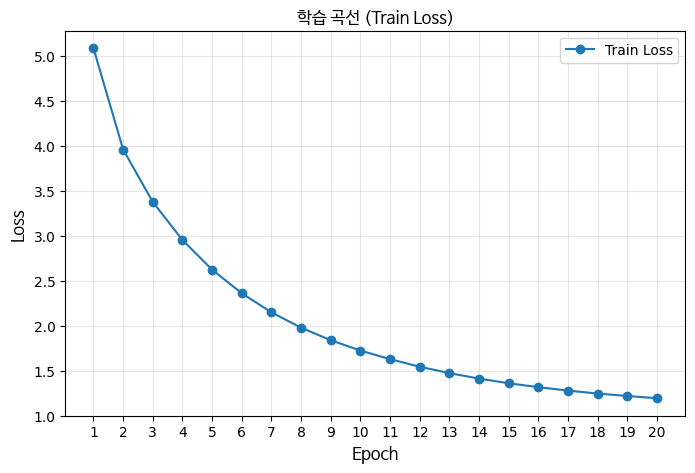

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Train Loss')
plt.title("학습 곡선 (Train Loss)", fontproperties=fontprop)
plt.xlabel("Epoch", fontproperties=fontprop)
plt.ylabel("Loss", fontproperties=fontprop)
plt.xticks(range(1, len(train_losses) + 1))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, mecab, max_len=60, eos_id=2):
    model.eval()

    # 한국어 입력이므로 Mecab 기반 전처리 사용
    sentence_processed = preprocess_sentence_ko(sentence, mecab)

    src_ids = encoder_tokenizer.encode(sentence_processed, out_type=int)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, trg=None, max_len=53, eos_id=eos_id)

    pred_ids = outputs.argmax(2).squeeze(1).tolist()

    # 토큰 id 기준(eos_id)으로 잘라줌
    if eos_id in pred_ids:
        pred_ids = pred_ids[:pred_ids.index(eos_id)]

    # Attention 시각화용 subword 조각
    result_pieces = [decoder_tokenizer.id_to_piece(i) for i in pred_ids]

    # 사람이 읽을 수 있는 최종 번역 문장
    translated_sentence = decoder_tokenizer.decode(pred_ids)

    return result_pieces, translated_sentence, sentence_processed, attentions.squeeze(1).cpu().numpy()

In [ ]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, rotation=90, fontproperties=fontprop)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontproperties=fontprop)

    plt.show()

In [ ]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, mecab, max_len=60):
    result_pieces, translated_sentence, src_processed, attention = evaluate(
        sentence, model, encoder_tokenizer, decoder_tokenizer, mecab, max_len=max_len
    )

    print('Input: %s' % (sentence))
    print('Input (전처리): %s' % (src_processed))
    print('Predicted translation: %s' % (translated_sentence))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result_pieces), :len(src_processed.split())]

    plot_attention(attention, src_processed.split(), result_pieces)

Input: 오바마는 대통령이다.
Input (전처리): 오바마 는 대통령 이 다 .
Predicted translation: obama picks the truck to obama ' s president .


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


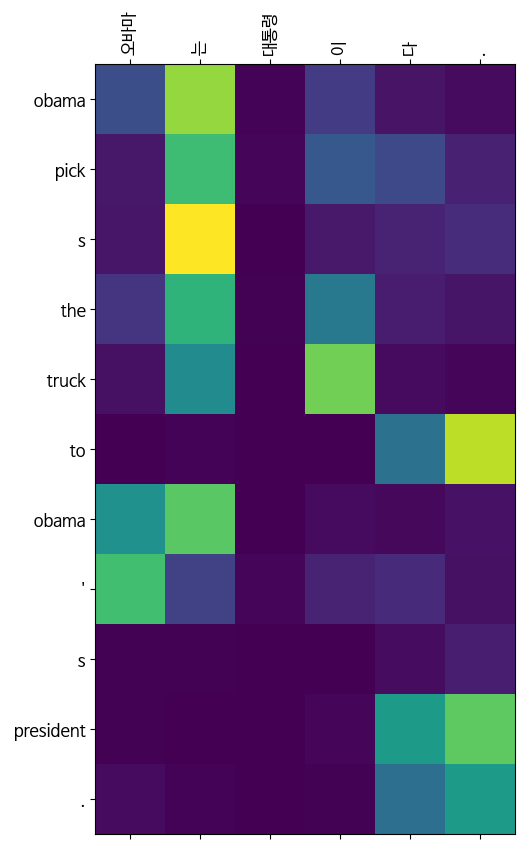

Input: 시민들은 도시 속에 산다.
Input (전처리): 시민 들 은 도시 속 에 산다 .
Predicted translation: citizens , citizens of civic civilians are citizens , particularly snakes and prompted their municipalities .


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


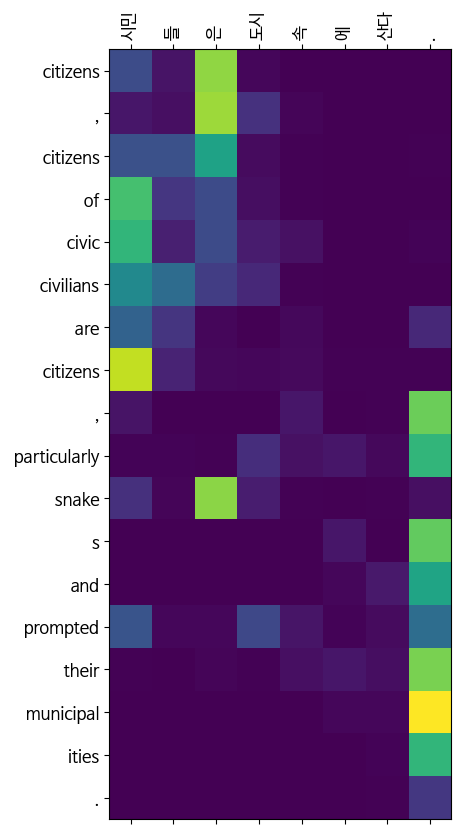

Input: 커피는 필요 없다.
Input (전처리): 커피 는 필요 없 다 .
Predicted translation: coffee is coffee donetsk needs coffee , coffee .


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


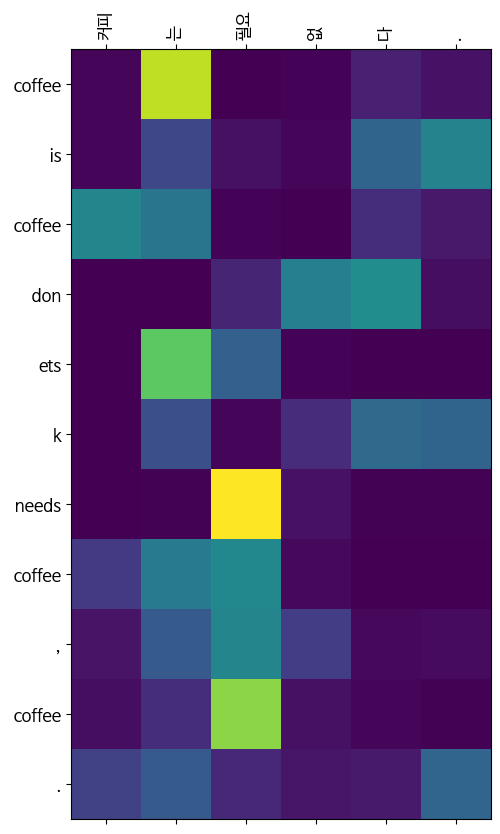

Input: 일곱 명의 사망자가 발생했다.
Input (전처리): 일곱 명 의 사망자 가 발생 했 다 .
Predicted translation: saturday , seven people were killed by seven days after the death stormed saturday .


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


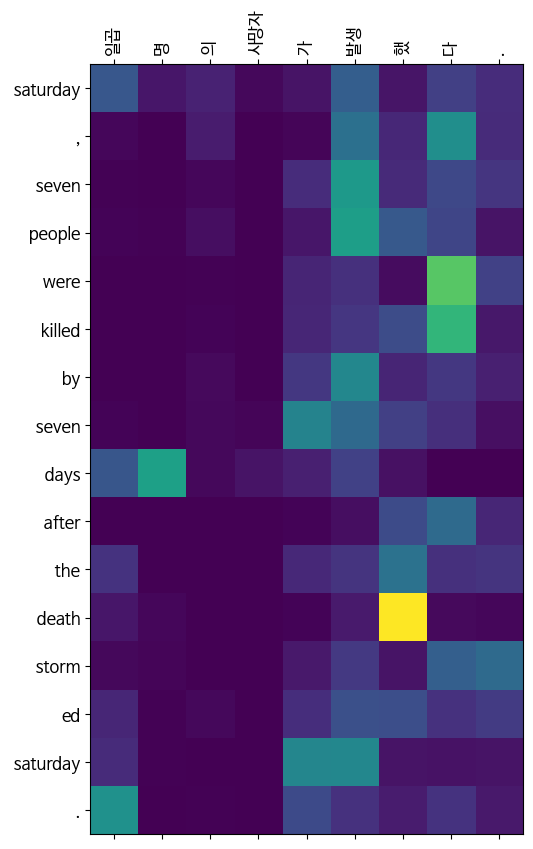

In [ ]:
sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for sentence in sentences:
    translate(sentence, model, encoder_tokenizer, decoder_tokenizer, mecab, max_len=60)
    print("=" * 60)

20 에포크로 학습을 진행했을 때의 결과가 아래와 같이 나타났으며 번역 품질 또한 매우 낮다. train loss와 test loss의 격차가 큰 것으로 보아 과적합이 있음을 알 수 있다.

**Train Loss: 1.1928**

**Final Test Loss: 6.3211**

- **1번 문장**

Input: 오바마는 대통령이다.

Input (전처리): 오바마 는 대통령 이 다 .

Predicted translation: obama picks the truck to obama ' s president .

- **2번 문장**

Input: 시민들은 도시 속에 산다.

Input (전처리): 시민 들 은 도시 속 에 산다 .

Predicted translation: citizens , citizens of civic civilians are citizens , particularly snakes and prompted their municipalities .

- **3번 문장**

Input: 커피는 필요 없다.

Input (전처리): 커피 는 필요 없 다 .

Predicted translation: coffee is coffee donetsk needs coffee , coffee .

- **4번 문장**

Input: 일곱 명의 사망자가 발생했다.

Input (전처리): 일곱 명 의 사망자 가 발생 했 다 .

Predicted translation: saturday , seven people were killed by seven days after the death stormed saturday .

# 성능 개선1

이를 해결하고자

- Dropout 추가
- 매 에폭마다 test loss도 같이 확인하며 과적합 확인
- Early Stopping
- teacher forcing ratio

기법을 적용하여 재학습을 진행한다.

기존 코드에서 아래와 같이 변경하였다.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

In [ ]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, dropout=0.3):
        super(Decoder, self).__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))

        a = self.attention(hidden[-1], encoder_outputs)
        a = a.unsqueeze(1)
        encoder_outputs_p = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, encoder_outputs_p)
        context = context.permute(1, 0, 2)

        output, hidden = self.rnn(embedded, hidden)

        output = output.squeeze(0)
        context = context.squeeze(0)
        prediction = self.fc_out(torch.cat((output, context), dim=1))

        return prediction, hidden, a.squeeze(1)

In [ ]:
import random

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=53, bos_id=1, eos_id=2, teacher_forcing_ratio=0.5):
        batch_size = src.shape[1]

        outputs = []
        attentions = []

        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            input = trg[0]  # 첫 입력은 <bos>
            for t in range(trg.shape[0]):
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

                teacher_force = random.random() < teacher_forcing_ratio
                top1 = output.argmax(1)
                input = trg[t] if teacher_force else top1

        else:
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)
        attentions = torch.cat(attentions, dim=0)

        return outputs, attentions

In [ ]:
encoder = Encoder(input_dim, emb_dim, hid_dim, dropout=0.3).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention, dropout=0.3).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

In [ ]:
def get_teacher_forcing_ratio(epoch, total_epochs, start=1.0, end=0.5):
    ratio = start - (start - end) * (epoch / total_epochs)
    return max(ratio, end)

In [ ]:
def train_step(model, data_loader, optimizer, criterion, epoch, teacher_forcing_ratio=1.0):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)
        src = src.transpose(0, 1)
        trg_input = trg_input.transpose(0, 1)
        trg_label = trg_label.transpose(0, 1)

        optimizer.zero_grad()
        outputs, _ = model(src, trg_input, teacher_forcing_ratio=teacher_forcing_ratio)

        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

In [ ]:
def eval_step(model, data_loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, trg_input, trg_label in data_loader:
            src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)

            # 학습과 동일하게 (seq_len, batch)로 전치
            src = src.transpose(0, 1)
            trg_input = trg_input.transpose(0, 1)
            trg_label = trg_label.transpose(0, 1)

            outputs, _ = model(src, trg_input, teacher_forcing_ratio=0.5)

            # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
            outputs = outputs.reshape(-1, outputs.shape[-1])
            trg_label = trg_label.reshape(-1)

            loss = criterion(outputs, trg_label)

            total_loss += loss.item()

    return total_loss / len(data_loader)

In [ ]:
%%time

best_test_loss = float('inf')
patience = 3
patience_counter = 0

EPOCHS = 30
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    test_loss = eval_step(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
        print("Best model 저장")
    else:
        patience_counter += 1
        print(f"Test loss 개선 없음 ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print("Early stopping!")
            break

Epoch 1: 100%|██████████| 1165/1165 [06:36<00:00,  2.94it/s, loss=5.65]


Epoch 1/30, Train Loss: 6.0878, Test Loss: 6.2089
Best model 저장


Epoch 2: 100%|██████████| 1165/1165 [06:35<00:00,  2.94it/s, loss=5.29]


Epoch 2/30, Train Loss: 5.3756, Test Loss: 6.0863
Best model 저장


Epoch 3: 100%|██████████| 1165/1165 [06:35<00:00,  2.94it/s, loss=4.87]


...

Epoch 4/30, Train Loss: 4.7564, Test Loss: 6.0842
Test loss 개선 없음 (1/3)


Epoch 5: 100%|██████████| 1165/1165 [06:36<00:00,  2.94it/s, loss=4.84]


Epoch 5/30, Train Loss: 4.5763, Test Loss: 6.1336
Test loss 개선 없음 (2/3)


Epoch 6: 100%|██████████| 1165/1165 [06:35<00:00,  2.94it/s, loss=4.55]


Epoch 6/30, Train Loss: 4.4405, Test Loss: 6.1838
Test loss 개선 없음 (3/3)
Early stopping!
CPU times: user 34min 22s, sys: 5min 14s, total: 39min 36s
Wall time: 39min 59s


In [ ]:
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()
print("Best model 로드 완료")

Best model 로드 완료


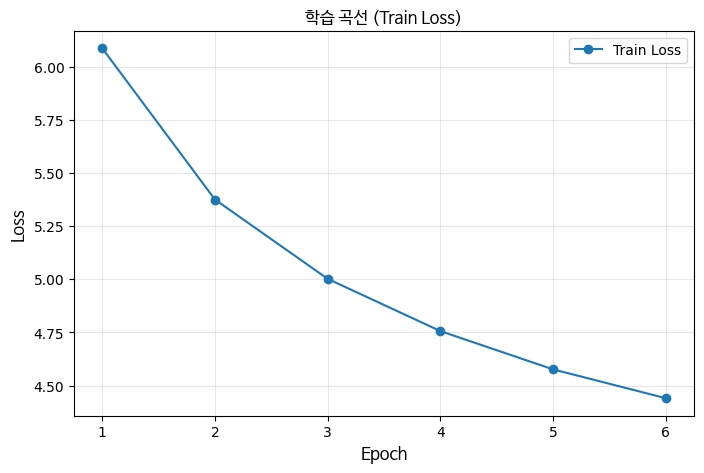

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Train Loss')
plt.title("학습 곡선 (Train Loss)", fontproperties=fontprop)
plt.xlabel("Epoch", fontproperties=fontprop)
plt.ylabel("Loss", fontproperties=fontprop)
plt.xticks(range(1, len(train_losses) + 1))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Input: 오바마는 대통령이다.
Input (전처리): 오바마 는 대통령 이 다 .
Predicted translation: obama obama s president


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


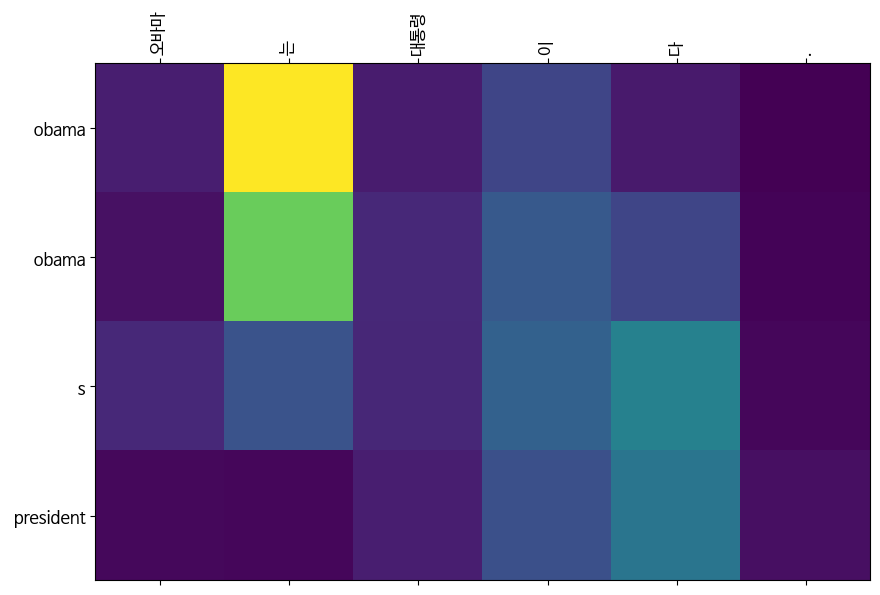

Input: 시민들은 도시 속에 산다.
Input (전처리): 시민 들 은 도시 속 에 산다 .
Predicted translation: there s citizens the of citizens thes cities


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


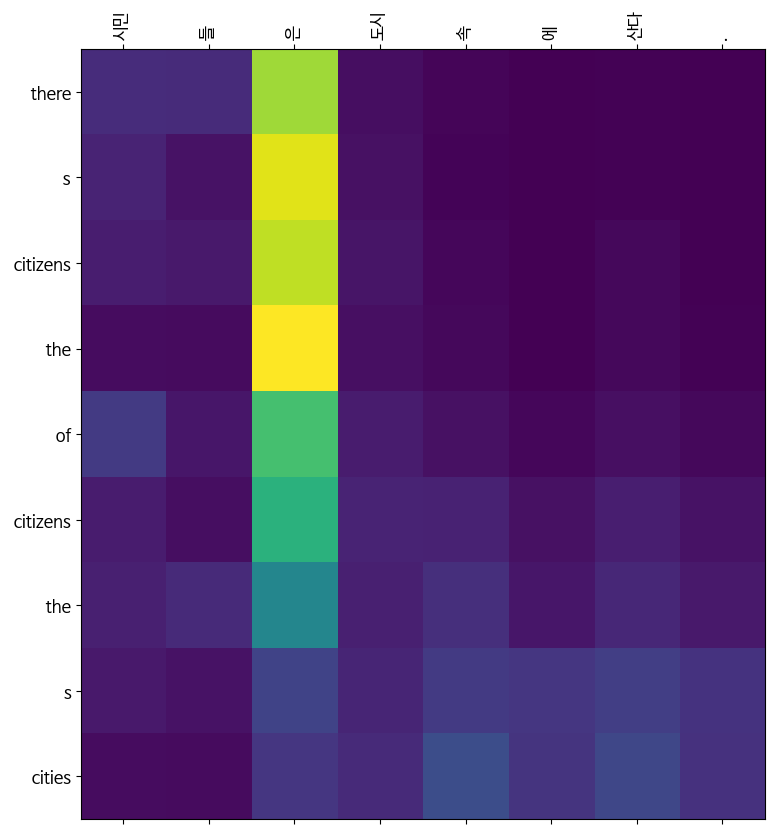

Input: 커피는 필요 없다.
Input (전처리): 커피 는 필요 없 다 .
Predicted translation: coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee needed need need


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


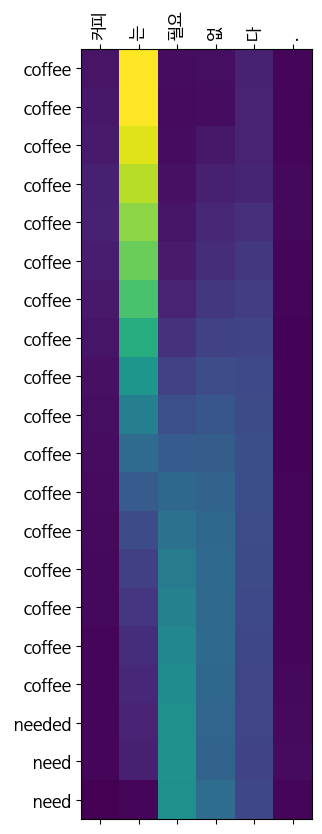

Input: 일곱 명의 사망자가 발생했다.
Input (전처리): 일곱 명 의 사망자 가 발생 했 다 .
Predicted translation: the deaths wednesday death death monday killing least people killed


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


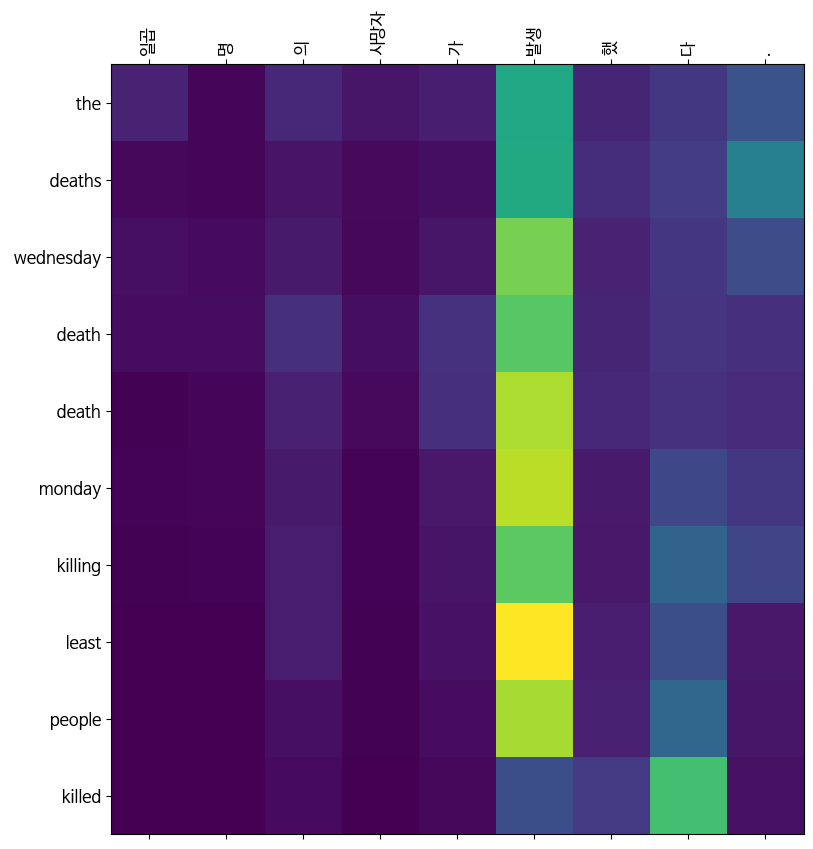

In [ ]:
sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for sentence in sentences:
    translate(sentence, model, encoder_tokenizer, decoder_tokenizer, mecab, max_len=60)
    print("=" * 60)

# 성능 개선2

여전히 예측 성능이 좋지 않은데 이는 데이터셋의 크기가 너무 작고 모델도 단순하기 때문으로 예측된다.

특히

커피는 필요 없다.

-> Predicted translation: coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee coffee needed need need

로 예측된 문장을 보면 모델이 특정 단어에 지나치게 확신을 갖고 같은 단어를 뽑는 것을 확인 할 수 있다.

이를 해결하고자 Encoder를 양방향(Bidirectional GRU)으로 구성하고 Label Smoothing를 적용하여 재학습을 진행한다.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(emb_dim, hidden_dim, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim)  # 양방향 결과를 hidden_dim으로 투영

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        # outputs: (src_len, batch, hidden_dim*2) -> decoder attention과 맞추기 위해 투영
        outputs = torch.tanh(self.fc(outputs))
        # hidden: (2, batch, hidden_dim) [forward/backward] -> 하나로 합쳐서 decoder 초기 hidden으로 사용
        hidden = torch.tanh(self.fc(torch.cat((hidden[0], hidden[1]), dim=1))).unsqueeze(0)
        return outputs, hidden

In [ ]:
encoder = Encoder(input_dim, emb_dim, hid_dim, dropout=0.3).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention, dropout=0.3).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id, label_smoothing=0.1)

In [ ]:
%%time

best_test_loss = float('inf')
patience = 3
patience_counter = 0

EPOCHS = 30
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    test_loss = eval_step(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
        print("Best model 저장")
    else:
        patience_counter += 1
        print(f"Test loss 개선 없음 ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print("Early stopping!")
            break

Epoch 1: 100%|██████████| 1165/1165 [06:56<00:00,  2.79it/s, loss=6.35]


Epoch 1/30, Train Loss: 6.5380, Test Loss: 6.6652
Best model 저장


Epoch 2: 100%|██████████| 1165/1165 [06:52<00:00,  2.83it/s, loss=5.75]


Epoch 2/30, Train Loss: 5.9805, Test Loss: 6.5286
Best model 저장


Epoch 3: 100%|██████████| 1165/1165 [06:53<00:00,  2.82it/s, loss=5.86]


...

Epoch 4/30, Train Loss: 5.5051, Test Loss: 6.5477
Test loss 개선 없음 (1/3)


Epoch 5: 100%|██████████| 1165/1165 [06:52<00:00,  2.83it/s, loss=5.44]


Epoch 5/30, Train Loss: 5.3699, Test Loss: 6.5287
Test loss 개선 없음 (2/3)


Epoch 6: 100%|██████████| 1165/1165 [06:52<00:00,  2.83it/s, loss=5.5]


Epoch 6/30, Train Loss: 5.2660, Test Loss: 6.6073
Test loss 개선 없음 (3/3)
Early stopping!
CPU times: user 35min 51s, sys: 5min 19s, total: 41min 11s
Wall time: 41min 43s


In [ ]:
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()
print("Best model 로드 완료")

Best model 로드 완료


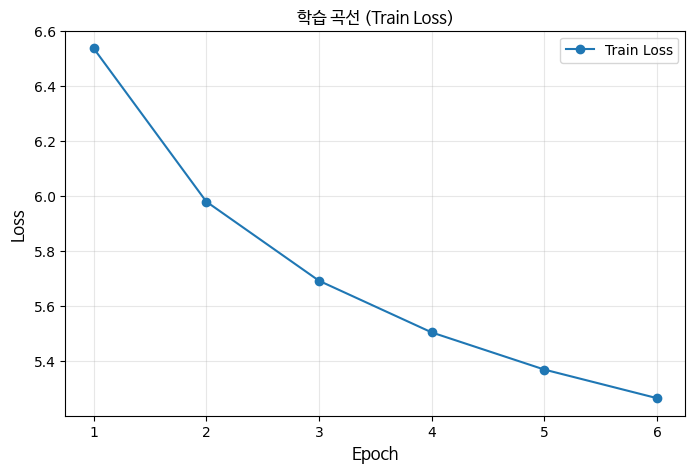

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Train Loss')
plt.title("학습 곡선 (Train Loss)", fontproperties=fontprop)
plt.xlabel("Epoch", fontproperties=fontprop)
plt.ylabel("Loss", fontproperties=fontprop)
plt.xticks(range(1, len(train_losses) + 1))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Input: 오바마는 대통령이다.
Input (전처리): 오바마 는 대통령 이 다 .
Predicted translation: obama sept


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


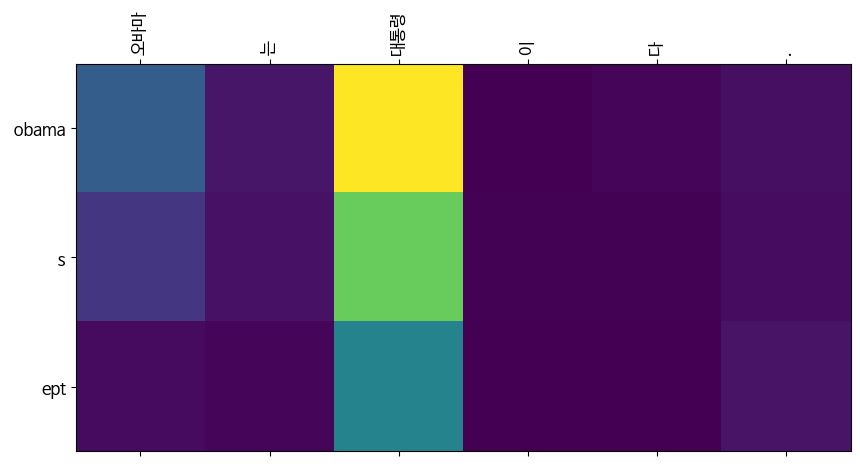

Input: 시민들은 도시 속에 산다.
Input (전처리): 시민 들 은 도시 속 에 산다 .
Predicted translation: the are to the city


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


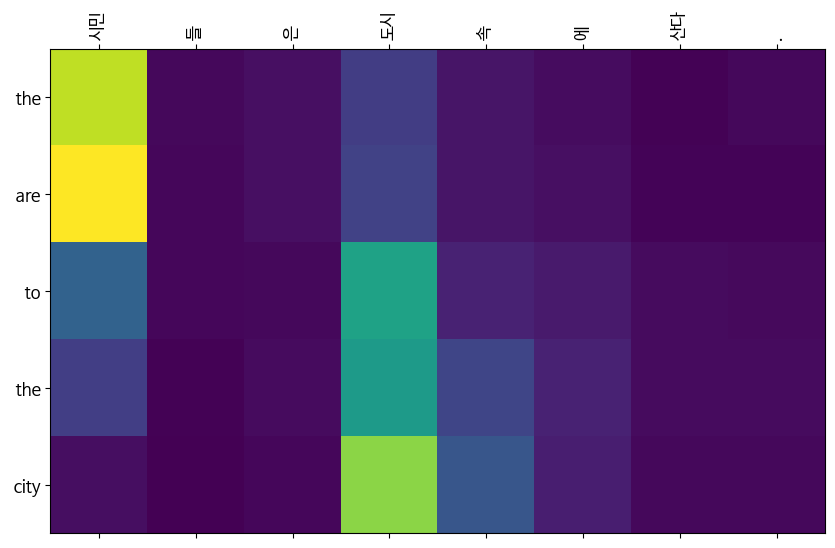

Input: 커피는 필요 없다.
Input (전처리): 커피 는 필요 없 다 .
Predicted translation: coffee coffee


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


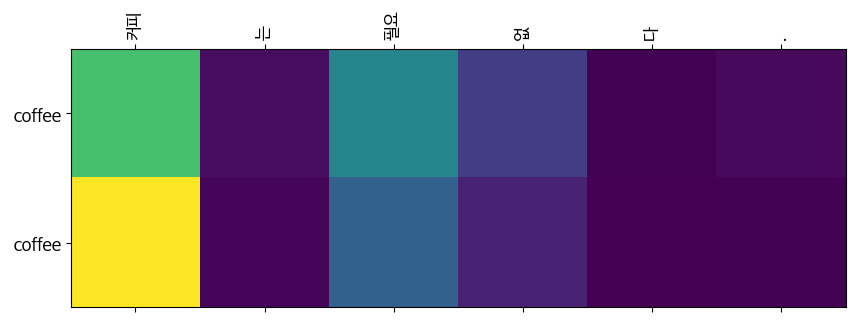

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


Input: 일곱 명의 사망자가 발생했다.
Input (전처리): 일곱 명 의 사망자 가 발생 했 다 .
Predicted translation: the dead the toll


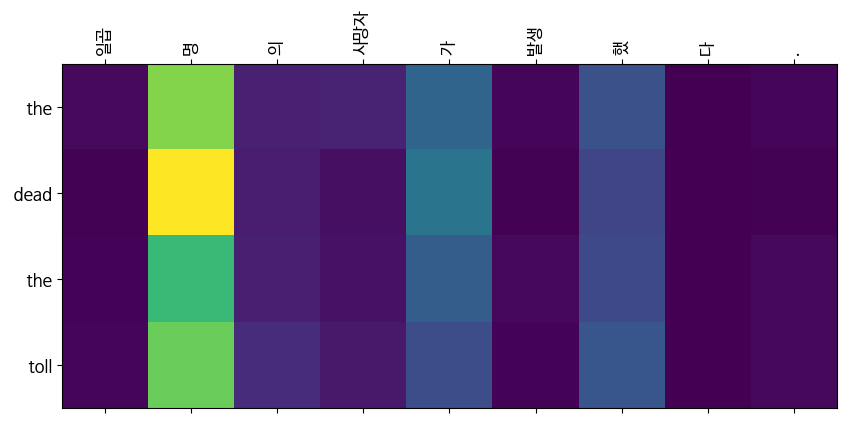

In [ ]:
sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for sentence in sentences:
    translate(sentence, model, encoder_tokenizer, decoder_tokenizer, mecab, max_len=60)
    print("=" * 60)

# 결과 분석

## 1. 정량적 비교 (Loss)

| 실험 | 구성 | Epoch (종료) | Train Loss | Test Loss (Best) | Train-Test 격차 |
|---|---|---|---|---|---|
| **Baseline** | GRU 1개, Dropout 없음, TF=100% | 20 (전체 완주) | 1.19 | 6.32 (최종) | **5.13** |
| **모델 2** | + Dropout + Early Stopping + TF ratio(0.5) | 6 (조기 종료) | 4.44 | **6.04** (epoch 3) | 1.60 |
| **모델 3** | 모델 2 + Bidirectional Encoder + Label Smoothing | 6 (조기 종료) | 5.27 | 6.51 (epoch 3) | 1.24 |

## 2. 정성적 비교 (번역 결과)

| 문장 | Baseline | 모델 2 | 모델 3 |
|---|---|---|---|
| 오바마는 대통령이다 | obama picks the truck to obama's president. | obama obama s president | obama sept |
| 시민들은 도시 속에 산다 | citizens, citizens of civic civilians... | there s citizens the of citizens... | the are to the city |
| 커피는 필요 없다 | coffee is coffee donetsk needs coffee, coffee. | coffee coffee coffee ×17 | coffee coffee |
| 일곱 명의 사망자가 발생했다 | saturday, seven people were killed... | the deaths wednesday death death... | the dead the toll |

## 3. 분석

### Train-Test 격차(과적합)는 확실히 개선됨
Dropout + Early Stopping을 추가하면서 baseline의 심각한 과적합(격차 5.13)이 모델 2(1.60), 모델 3(1.24)로 크게 줄었습니다. 이 부분은 의도한 대로 작동했습니다.

### 하지만 절대적인 번역 품질은 오히려 후퇴함
Test Loss의 절대값 자체는 baseline이 가장 낮았던 순간(최종 6.32)과 모델 2·3의 best 값(6.04, 6.51)이 별 차이가 없거나 더 나쁩니다.

실제 번역 결과도 baseline이 문법은 깨져도 그나마 문맥 관련 단어를 뱉는 반면 모델 3으로 갈수록 출력이 극도로 짧고 의미 없는 조각("coffee coffee", "the dead the toll")으로 퇴화했습니다.

## 4. 실험 종료 판단

세 실험을 종합 해보면 지금 성능의 한계는 특정 하이퍼파라미터 하나를 조정해서 해결될 문제라기보다 **데이터셋 규모와 모델 구조의 근본적인 한계**에 가깝다고 판단됩니다.

- 학습 데이터가 약 7만 문장 규모로 뉴스 도메인 특유의 긴 문장과 복잡한 문법 구조를 학습하기에는 충분하지 않은 양입니다.
- 모델 역시 GRU 1개 층으로 구성된 비교적 단순한 구조라 표현력 자체에 한계가 있습니다.
- 이 상황에서 GRU 층을 더 쌓아 모델 용량을 늘리는 방법도 고려할 수 있지만 지금처럼 데이터가 제한적인 상태에서 파라미터 수만 늘리면 모델이 학습 데이터를 다시 암기해버리는 과적합이 재발할 위험이 큽니다. 실제로 Dropout과 Early Stopping으로 어렵게 억제해 놓은 과적합(격차 5.13 → 1.2~1.6)이 층을 늘리는 순간 다시 벌어질 가능성이 높습니다.

따라서 데이터셋 규모 대비 모델 구조를 더 키우는 방향은 리스크가 크다고 판단하여 여기서 실험을 마무리합니다.